In [2]:
import sys, os

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import MaxPooling2D, Flatten, Conv2D, Dense
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

import cv2, imghdr
from matplotlib import pyplot as plt
import numpy as np

import random
from pathlib import Path

In [3]:
folders = ['test_Apple', 'test_Orange']
len_fol, fol_images = [], []
for f in folders:
    images = []
    for fi in Path(f).iterdir():
        images.append(fi)
    fol_images.append(images)
    len_fol.append(len(images))
n_model = load_model(os.path.join('models', 'imageClassifierAppleOrange.h5'))

## Connection to Arduino

**PySerial**: A Python module that provides access to the serial port. It allows Python programs to communicate
with devices connected via serial ports

In [3]:
pip install pyserial


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import serial
import time

In [77]:
def send_command(cmd, percent):
    arduino.write(f"{cmd},{percent:.2f}\n".encode())
    
def gen_ran_numbers():
    ran_fol = random.randint(0, len(folders)-1)
    ran_file = random.randint(0, len_fol[ran_fol]-1)
    return ran_fol, ran_file
def shows_img(fo, fi):
    img = cv2.cvtColor(cv2.imread(fol_images[fo][fi]), cv2.COLOR_BGR2RGB)
    resize = tf.image.resize(img, (256, 256))
    plt.imshow(resize.numpy().astype(int))
    plt.show()
    return resize
def pred(img):
    raw_yhat = n_model.predict(np.expand_dims(img/255, 0))
    yhat = float(raw_yhat[0][0])
    print(f"{yhat:.2f}")
    if raw_yhat < 0.5: 
        yhat = (1-yhat)*100
        send_command('A', yhat)
        print(f'Predicted class is an Apple')
    else: 
        yhat *= 100
        send_command('O', yhat)
        print(f'Predicted class is an Orange')

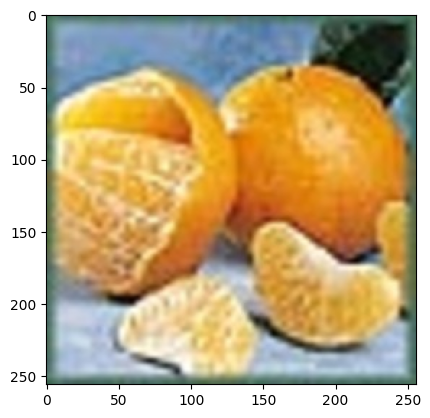

Folder: test_Orange, Image name: test_Orange\n07749192_3191.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1.00
Predicted class is an Orange


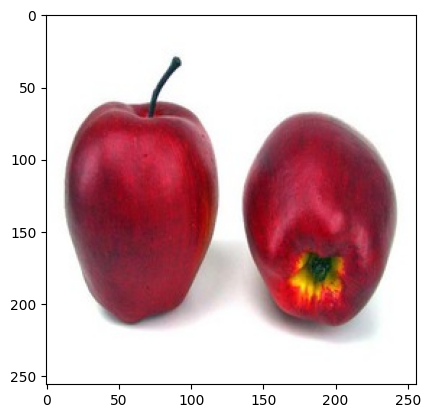

Folder: test_Apple, Image name: test_Apple\n07740461_2510.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
0.00
Predicted class is an Apple


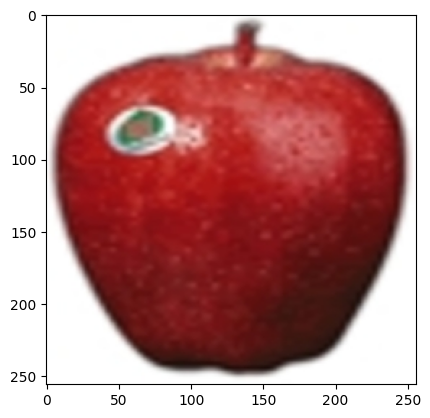

Folder: test_Apple, Image name: test_Apple\n07740461_7141.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
0.00
Predicted class is an Apple


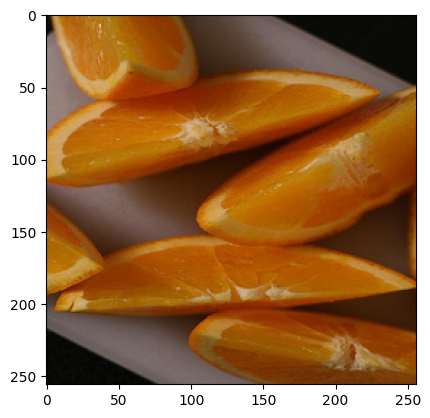

Folder: test_Orange, Image name: test_Orange\n07749192_5241.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1.00
Predicted class is an Orange


KeyboardInterrupt: 

In [83]:
arduino = serial.Serial(port='COM4', baudrate=9600, timeout=1)
# baudrate: rate at which data is transferred in bits per second
time.sleep(2) # wait for connection

while True: 
    line = arduino.readline().decode().strip()
    if line == 'Switch ON':
        fo, fi = gen_ran_numbers()
        img = shows_img(fo, fi)
        print(f"Folder: {folders[fo]}, Image name: {fol_images[fo][fi]}\n")
        pred(img)
    # elif line == 'Switch OFF':
    #   send_command('F')

In [82]:
arduino.close()